In [1]:
! pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


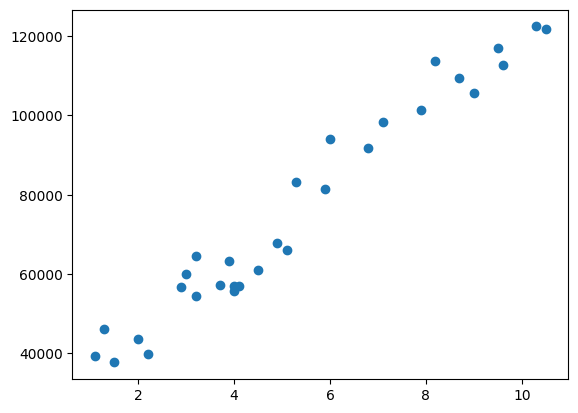

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

salary = pd.read_csv("data/salary.csv")

plt.scatter(x=salary["YearsExperience"], y=salary["Salary"])

<Axes: xlabel='YearsExperience', ylabel='Salary'>

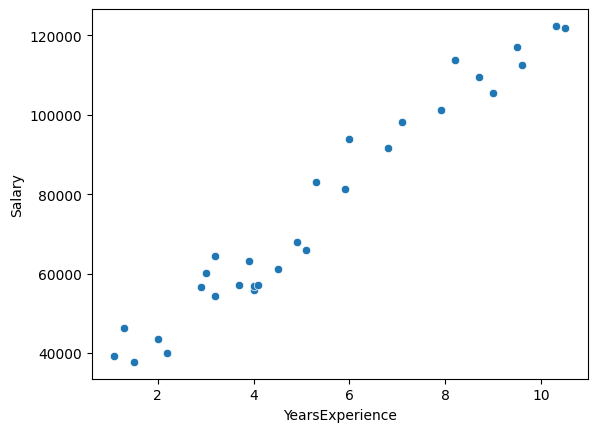

In [3]:
sns.scatterplot(x=salary["YearsExperience"], y=salary["Salary"])

# Regresja prosta

In [4]:
y = salary["Salary"]
x = salary.drop(columns=["Salary"])

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
model.intercept_

np.float64(25792.20019866871)

Wyraz wolny wynosi 25792 dolary - przy zerowym doświadczeniu roczne wynagrodzenie wynosi 25792 dolary.

In [7]:
model.coef_

array([9449.96232146])

Współczynnik kierunkowy wynosi 9449 dolary - wzrost liczby lat doświadczenia o 1 rok wiąże się ze średnim wzrostem wynagrodzenia o 9449 dolary.

y = 9449 * x + 25792
wynagrodzenie = 9449 * doświadczenie + 25792

## Ocena jakości modelu

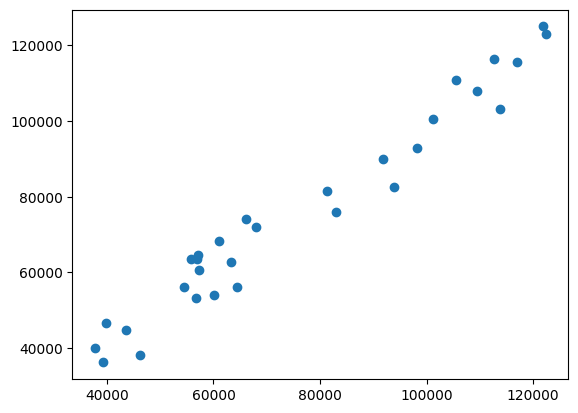

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = model.predict(x)

plt.scatter(x = y, y = y_pred)

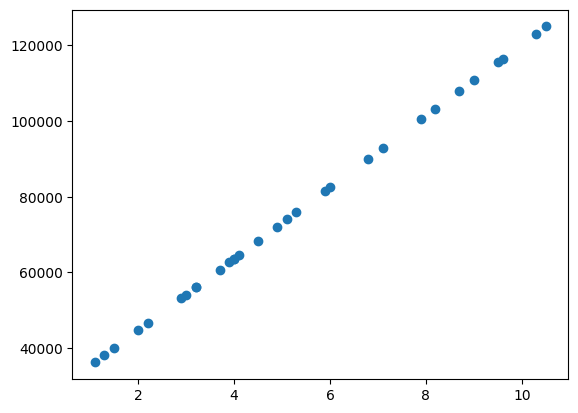

In [9]:
plt.scatter(x = x, y = y_pred)

In [10]:
print("R2:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", root_mean_squared_error(y, y_pred))

R2: 0.9569566641435086
MAE: 4644.2012894435375
MSE: 31270951.722280968
RMSE: 5592.043608760662


Współczynnik determinacji R2 wynosi 0,96 (96%), co oznacza, że model wyjaśnia 96% zmienności wynagrodzenia.

MAE wynosi 4644 dolary, co oznacza, że średni błąd bezwzględny wynosi 4644 dolary. 

RMSE wynosi 5592 dolary, co oznacza, że średni błąd modelu wynosi 5592 dolary.

In [11]:
! pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
model_sm = sm.OLS(y, x_const).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.14e-20
Time:                        11:35:41   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.579e+04   2273.053     

## Regresja wieloraka

In [13]:
insurance = pd.read_csv("data/insurance.csv")

In [14]:
insurance_num = insurance.drop(columns=["sex", "smoker", "region"])
correlations = insurance_num.corr()
correlations

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

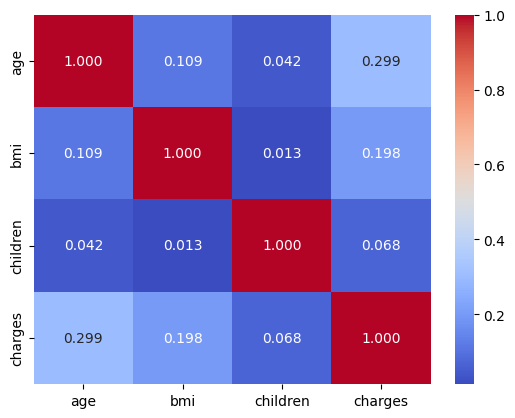

In [15]:
from seaborn import heatmap

heatmap(correlations, annot=True, cmap="coolwarm", fmt=".3f")

In [16]:
insurance_ohe = pd.get_dummies(insurance[["sex", "smoker", "region"]], dtype=int, drop_first=True)
insurance_ohe

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,0
3,1,0,1,0,0
4,1,0,1,0,0
...,...,...,...,...,...
1333,1,0,1,0,0
1334,0,0,0,0,0
1335,0,0,0,1,0
1336,0,0,0,0,1


In [17]:
insurance_encoded = pd.concat([insurance_num, insurance_ohe], axis=1)

x_insurance = insurance_encoded.drop(columns=["charges"])
y_insurance = insurance_encoded["charges"]

x_insurance_const = sm.add_constant(x_insurance)
model_insurance = sm.OLS(y_insurance, x_insurance_const).fit()
print(model_insurance.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:35:41   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

- wyraz wolny = -11940 dolarów - interpretacja wyrazu wolnego nie ma sensu ekonomicznego, ponieważ składka nie może być ujemna oraz wiek, bmi nie może być równe 0

- wiek = 256 - wzrost wieku o 1 rok wiąże się ze średnim wzrostem wysokości składki o 256 dolarów (ceteris paribus)

- bmi = 339 - wzrost bmi o 1 wiąże się ze średnim wzrostem wysokości składki o 339 dolarów (ceteris paribus)

- children = 475 - wzrost liczby dzieci o 1 wiąże się ze średnim wzrostem wysokości składki o 475 dolarów (ceteris paribus)

- sex_male = -131 - bycie mężczyzną wiąże się ze średnim poziomem składki niższym o 131 dolarów w porównaniu do kobiet (ceteris paribus)

- smoker_yes = 23850 - bycie palaczem wiąże się ze średnim poziomem składki wyższym o 23850 dolarów w porównaniu do niepalących (ceteris paribus)

- region_northwest = -352 - mieszkanie w regionie północno-zachodnim wiąże się ze średnim poziomem składki niższym o 352 dolary w porównaniu do regionu northeast (północno-wschodniego) (ceteris paribus)

- region_southeast = -1035 - mieszkanie w regionie południowo-wschodnim wiąże się ze średnim poziomem składki niższym o 1035 dolary w porównaniu do regionu northeast (północno-wschodniego) (ceteris paribus)

In [18]:
# usuwamy z modelu sex_male
x_insurance = insurance_encoded.drop(columns=["charges", "sex_male"])
y_insurance = insurance_encoded["charges"]

x_insurance_const = sm.add_constant(x_insurance)
model_insurance = sm.OLS(y_insurance, x_insurance_const).fit()
print(model_insurance.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:35:41   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.199e+04    978.762  

### Analiza rozkładu reszt

In [19]:
residuals = model_insurance.resid
residuals

0       -8332.973406
1       -1786.613459
2       -2320.800752
3       18157.413783
4       -1794.482182
            ...     
1333    -1817.822068
1334    -1239.449037
1335    -2450.852873
1336      823.596671
1337    -7872.857757
Length: 1338, dtype: float64

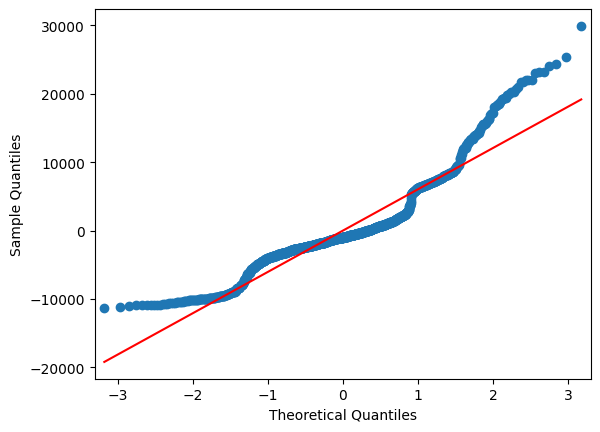

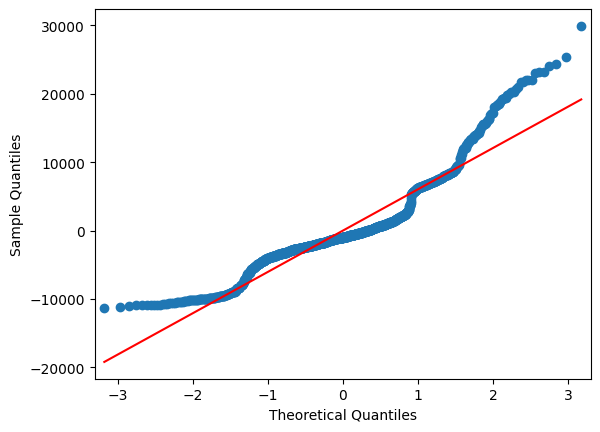

In [20]:
sm.qqplot(residuals, line="s")

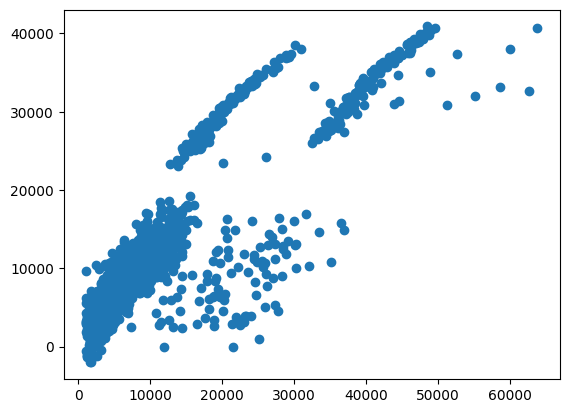

In [21]:
pred_insurance = model_insurance.predict(x_insurance_const)
plt.scatter(y_insurance, pred_insurance)

### Wartości odstające

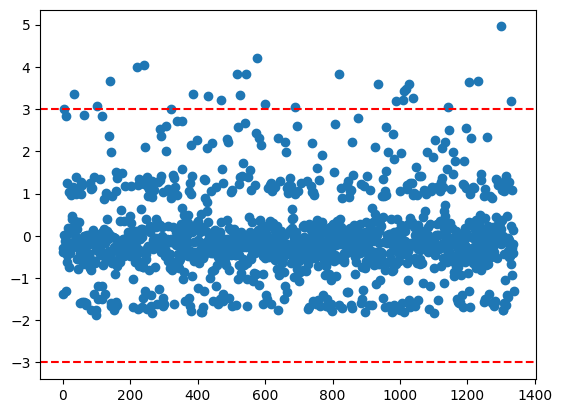

In [22]:
influence = model_insurance.get_influence()

residuals_stud = influence.get_resid_studentized_external()
residuals_stud

plt.scatter(range(len(residuals_stud)), residuals_stud)
plt.axhline(y=3, color="r", linestyle="--")
plt.axhline(y=-3, color="r", linestyle="--")

In [23]:
import numpy as np

outliers_resid = residuals_stud[np.abs(residuals_stud) > 3]
len(outliers_resid)

28

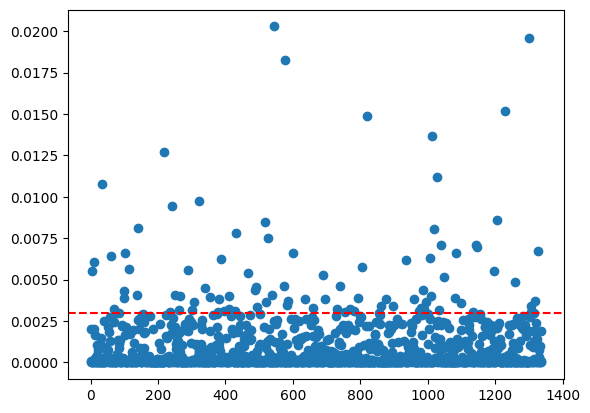

In [24]:
cooks_d = influence.cooks_distance[0]
cooks_d

threshold = 4/len(cooks_d)

plt.scatter(range(len(cooks_d)), cooks_d)
plt.axhline(y=threshold, color="r", linestyle="--")

In [25]:
outliers_cooks = cooks_d[cooks_d > threshold]
len(outliers_cooks)

92

### Usunięcie wartości odstających

In [26]:
indicies_outliers_cook = np.where(cooks_d > threshold)[0]
indicies_outliers_resid = np.where(np.abs(residuals_stud) > 3)[0]
print("Cook", indicies_outliers_cook)
print("Resid", indicies_outliers_resid)

Cook [   3    9   34   62   69   85   98   99  102  115  138  140  219  235
  242  250  262  266  289  301  306  321  340  355  379  380  387  397
  411  412  429  430  468  488  491  494  516  520  526  539  543  573
  577  583  587  599  637  661  688  696  730  739  754  770  780  793
  806  819  854  860  876  896  936  959  975  980  987  989  994 1008
 1011 1012 1019 1027 1033 1039 1047 1080 1085 1100 1134 1142 1146 1195
 1206 1230 1258 1300 1306 1307 1317 1328]
Resid [   3   34  102  140  219  242  387  430  468  516  526  543  577  599
  688  819  936  987 1008 1012 1019 1027 1039 1142 1206 1230 1300 1328]


In [27]:
x_insurance_no_outliers = x_insurance_const.drop(index=indicies_outliers_cook)
y_insurance_no_outliers = y_insurance.drop(index=indicies_outliers_cook)

model_insurance = sm.OLS(y_insurance_no_outliers, x_insurance_no_outliers).fit()
print(model_insurance.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     1016.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:35:42   Log-Likelihood:                -12231.
No. Observations:                1246   AIC:                         2.448e+04
Df Residuals:                    1238   BIC:                         2.452e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.076e+04    762.144  

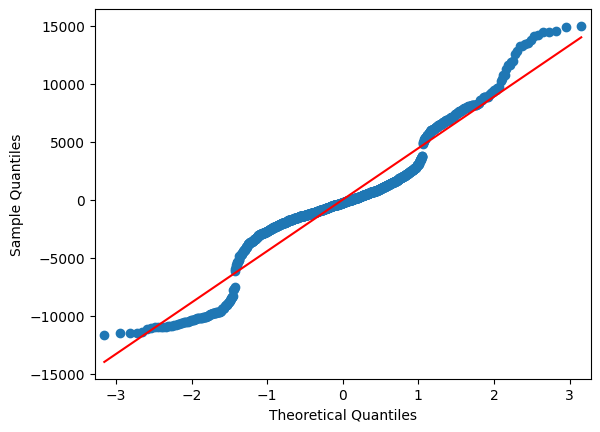

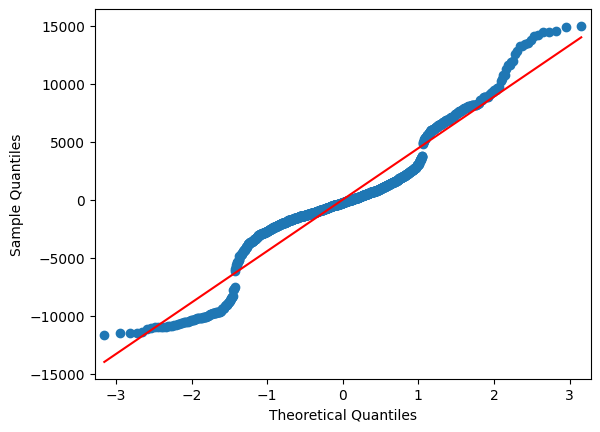

In [28]:
sm.qqplot(model_insurance.resid, line="s")

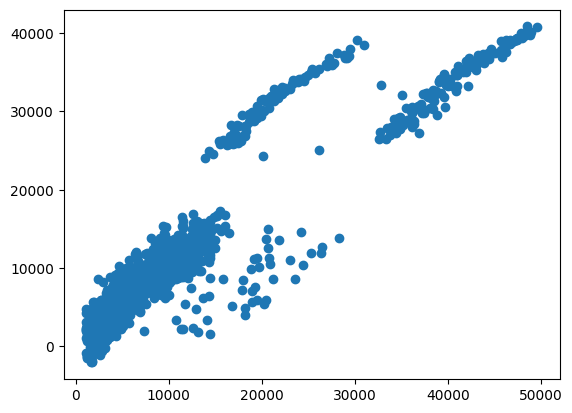

In [29]:
pred_insurance = model_insurance.predict(x_insurance_no_outliers)
plt.scatter(y_insurance_no_outliers, pred_insurance)

In [30]:
print("MAE", mean_absolute_error(y_insurance_no_outliers, pred_insurance))
print("RMSE", root_mean_squared_error(y_insurance_no_outliers, pred_insurance))

MAE 3014.1204225784895
RMSE 4435.345431058353


## Zadanie

<Axes: >

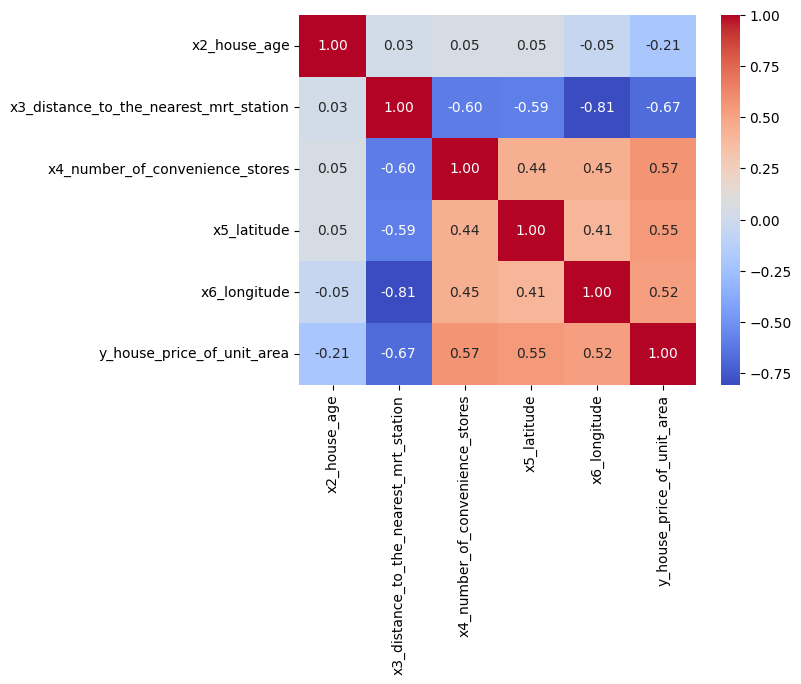

In [31]:
from janitor import clean_names

real_estate = pd.read_csv("data/real_estate.csv")
real_estate = real_estate.clean_names()

real_estate_columns = real_estate.drop(columns=["no", "x1_transaction_date"])

correlations = real_estate_columns.corr()
heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f')

In [32]:
x_real_estate = real_estate_columns.drop(columns=["y_house_price_of_unit_area"])
y_real_estate = real_estate_columns["y_house_price_of_unit_area"]

x_real_estate_const = sm.add_constant(x_real_estate)
model_real_estate = sm.OLS(y_real_estate, x_real_estate_const).fit()
print(model_real_estate.summary())

                                OLS Regression Results                                
Dep. Variable:     y_house_price_of_unit_area   R-squared:                       0.571
Model:                                    OLS   Adj. R-squared:                  0.566
Method:                         Least Squares   F-statistic:                     108.7
Date:                        Sat, 18 Apr 2026   Prob (F-statistic):           9.34e-73
Time:                                11:48:35   Log-Likelihood:                -1492.4
No. Observations:                         414   AIC:                             2997.
Df Residuals:                             408   BIC:                             3021.
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

In [33]:
x_real_estate = real_estate_columns.drop(columns=["y_house_price_of_unit_area", "x6_longitude"])
y_real_estate = real_estate_columns["y_house_price_of_unit_area"]

x_real_estate_const = sm.add_constant(x_real_estate)
model_real_estate = sm.OLS(y_real_estate, x_real_estate_const).fit()
print(model_real_estate.summary())

                                OLS Regression Results                                
Dep. Variable:     y_house_price_of_unit_area   R-squared:                       0.571
Model:                                    OLS   Adj. R-squared:                  0.567
Method:                         Least Squares   F-statistic:                     136.2
Date:                        Sat, 18 Apr 2026   Prob (F-statistic):           7.60e-74
Time:                                11:48:35   Log-Likelihood:                -1492.5
No. Observations:                         414   AIC:                             2995.
Df Residuals:                             409   BIC:                             3015.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

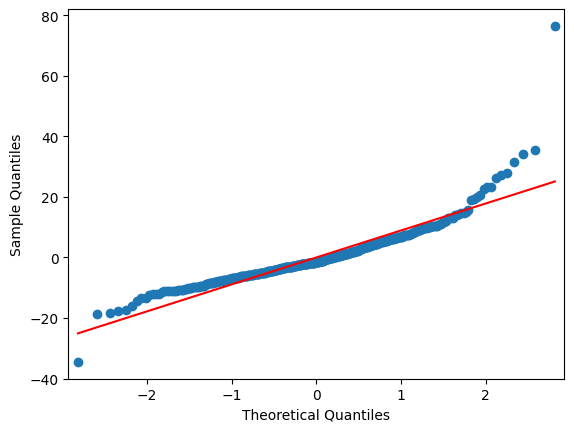

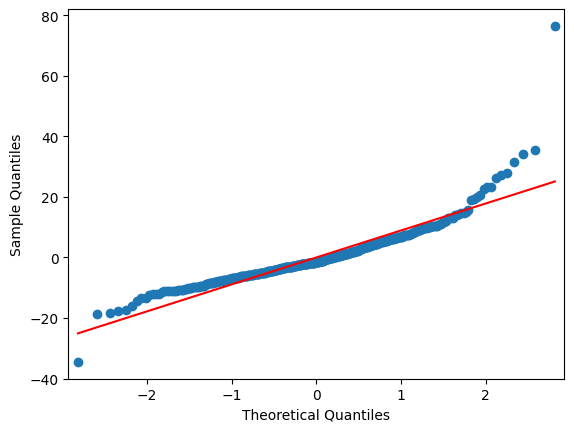

In [34]:
sm.qqplot(model_real_estate.resid, line='s')

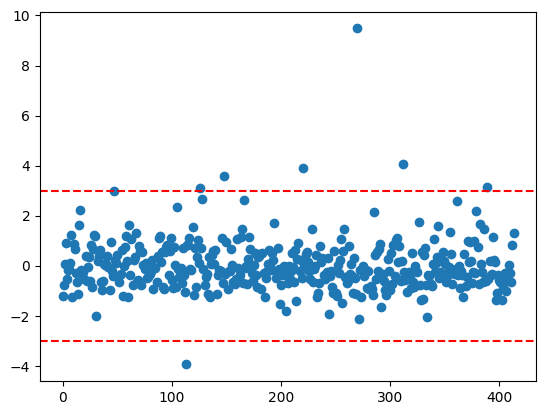

In [35]:
influence = model_real_estate.get_influence()

residuals_studentized = influence.resid_studentized_external

plt.scatter(range(len(residuals_studentized)), residuals_studentized)
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--')

outliers_resid = residuals_studentized[np.abs(residuals_studentized) > 3]

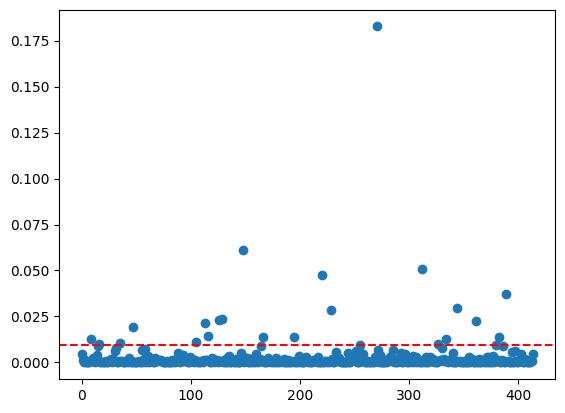

In [36]:
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

plt.scatter(range(len(cooks_d)), cooks_d)
plt.axhline(y=threshold, color='r', linestyle='--')

outliers_cooks = cooks_d[cooks_d > threshold]

In [37]:
indices_outliers_cooks = np.where(cooks_d > threshold)[0]
indices_outliers_resid = np.where(np.abs(residuals_studentized) > 3)[0]
print("Outliers based on Cook's distance:", indices_outliers_cooks)
print("Outliers based on Studentized residuals:", indices_outliers_resid)

Outliers based on Cook's distance: [  8  16  35  47 105 113 116 126 128 148 166 194 220 228 255 270 312 326
 334 344 361 379 382 389]
Outliers based on Studentized residuals: [113 126 148 220 270 312 389]


In [38]:
x_real_estate_no_outliers = x_real_estate.drop(index=indices_outliers_cooks)
y_real_estate_no_outliers = y_real_estate.drop(index=indices_outliers_cooks)

x_real_estate_no_outliers_const = sm.add_constant(x_real_estate_no_outliers)
model_real_estate = sm.OLS(y_real_estate_no_outliers, x_real_estate_no_outliers_const).fit()
print(model_real_estate.summary())

                                OLS Regression Results                                
Dep. Variable:     y_house_price_of_unit_area   R-squared:                       0.729
Model:                                    OLS   Adj. R-squared:                  0.727
Method:                         Least Squares   F-statistic:                     259.5
Date:                        Sat, 18 Apr 2026   Prob (F-statistic):          7.07e-108
Time:                                11:48:36   Log-Likelihood:                -1265.0
No. Observations:                         390   AIC:                             2540.
Df Residuals:                             385   BIC:                             2560.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

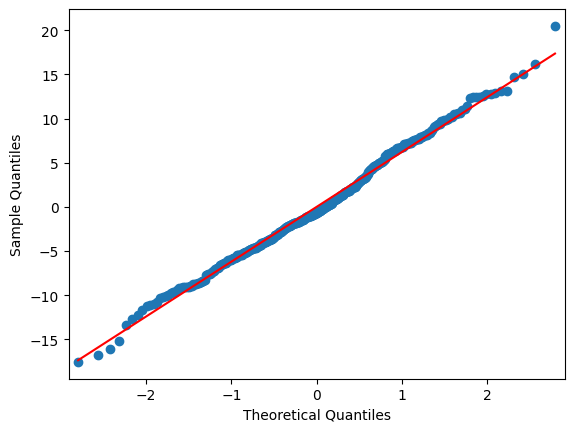

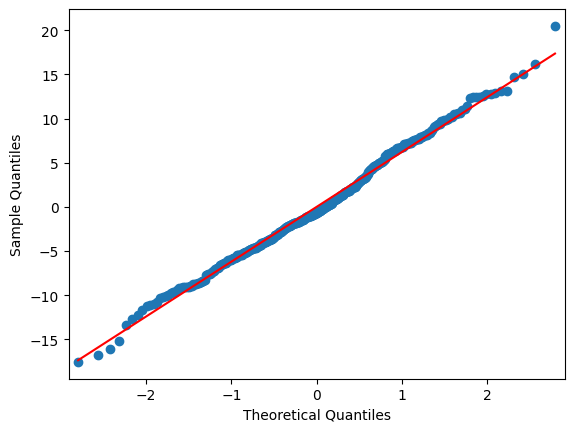

In [39]:
sm.qqplot(model_real_estate.resid, line='s')